Tạo 2 cột Order Hour Range (cách nhau 6 tiếng) và Order Count (số lượng đơn hàng) để rút ra insight trong quá khứ thông qua các biểu đồ:
- Khung giờ có nhiều đơn hàng nhất là từ 6:00 PM tới 12:00 AM hôm sau.
- Khung giờ có ít đơn hàng nhất là từ 6:00 AM tới 12:00 PM:
  + 6AM - 8AM: Các khu vực như Gurugram, Noida, và Ghaziabad thường chứng kiến ùn tắc nhẹ đến trung bình ở các điểm nút.
  + 8AM - 10AM: Đây là giờ cao điểm chính, Khu vực trung tâm Delhi có thể bị tắc nghẽn do lượng xe lớn, Các khu công nghiệp ở Noida và Faridabad cũng làm tăng áp lực giao thông trên các tuyến đường.
  + 10AM - 12PM: Giao thông bắt đầu giảm dần sau giờ cao điểm, nhưng vẫn có thể đông ở những khu vực thương mại và văn phòng như Nehru Place, Saket, và Cyber City (Gurugram).


Một số điểm nóng giao thông thường gặp:
- Delhi-Gurugram Border (NH-48): Thường xuyên ùn tắc vào buổi sáng do lượng xe từ Gurugram vào Delhi.
- DND Flyway: Kết nối Noida với Delhi, dễ bị chậm trễ nếu có kiểm tra xe hoặc lưu lượng cao.
- Ghaziabad (NH-24/NH-9): Giao thông đông đúc do kết nối với phía đông Delhi.
- Ring Road: Các đoạn gần ISBT Kashmiri Gate, Sarai Kale Khan thường xuyên tắc nghẽn.


File này dùng để phân tích số lượng đơn hàng theo các khung thời gian cách nhau 6 tiếng.
Đã áp dụng auto arima và auto sarima (chỉ cần sửa 1 câu lệnh):
- auto arima: model = auto_arima(train_series, seasonal=False, stepwise=True, trace=True)
- auto sarima: model = auto_arima(train_series, seasonal=True, m=4, stepwise=True, trace=True)

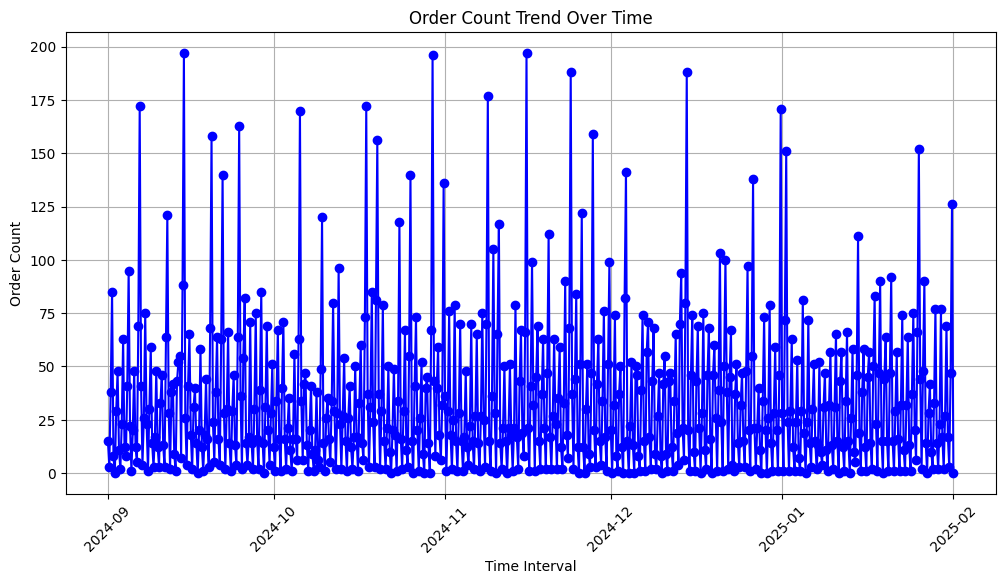

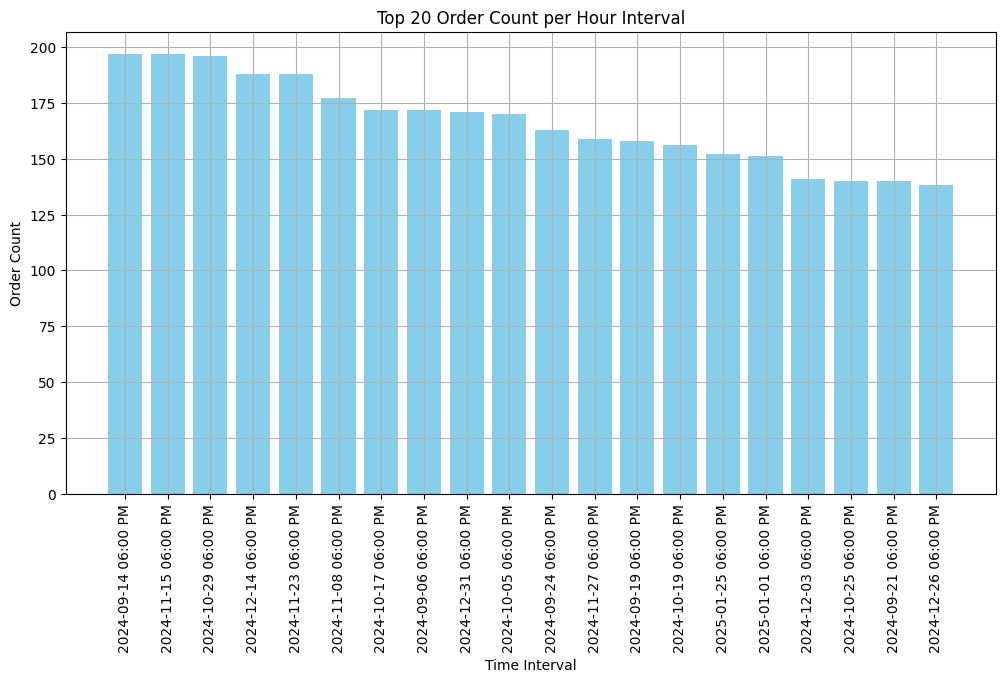

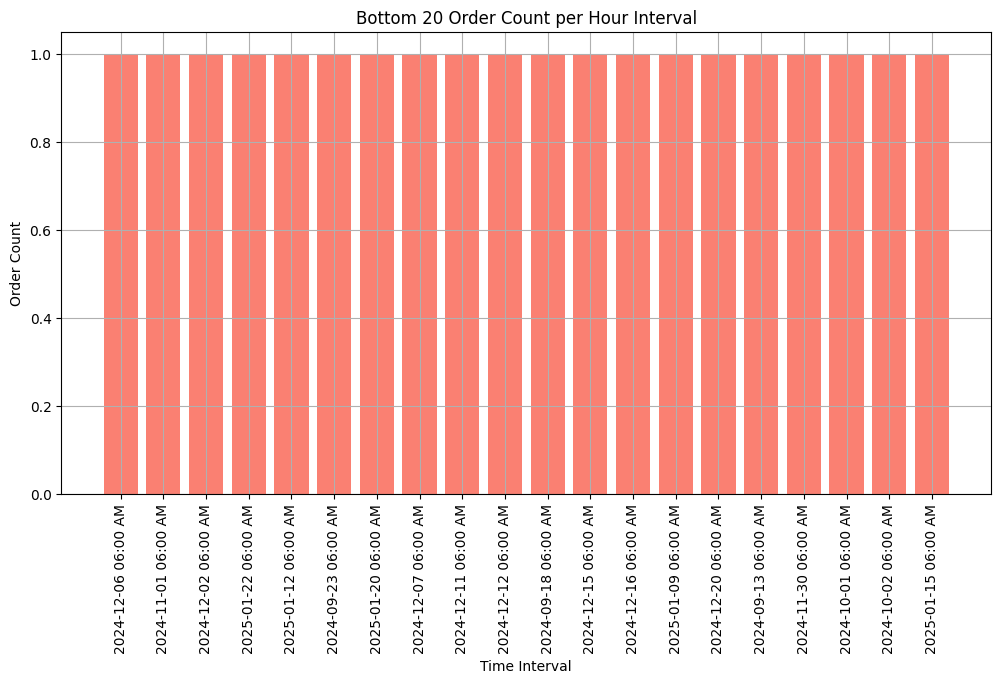


Bảng sắp xếp khung giờ theo số lượng đơn hàng tăng dần (100 dòng đầu tiên):
   Order Hour Range  Order Count
2025-02-01 00:00:00            0
2024-10-22 06:00:00            0
2024-11-12 06:00:00            0
2025-01-13 06:00:00            0
2025-01-11 06:00:00            0
2024-11-25 06:00:00            0
2024-11-26 06:00:00            0
2025-01-05 06:00:00            0
2024-12-29 06:00:00            0
2025-01-19 06:00:00            0
2024-12-01 06:00:00            0
2024-12-03 06:00:00            0
2024-12-04 06:00:00            0
2024-12-05 06:00:00            0
2024-09-29 06:00:00            0
2024-12-19 06:00:00            0
2024-10-29 06:00:00            0
2024-12-17 06:00:00            0
2024-12-10 06:00:00            0
2024-12-28 06:00:00            0
2024-11-10 06:00:00            0
2024-09-17 06:00:00            0
2024-10-28 06:00:00            0
2025-01-27 06:00:00            0
2024-09-02 06:00:00            0
2024-10-26 06:00:00            0
2024-11-03 06:00:00            1

,Order Count
Order Hour Range,
2024-09-01 00:00:00,15
2024-09-01 06:00:00,3
2024-09-01 12:00:00,38
2024-09-01 18:00:00,85
2024-09-02 00:00:00,8
...,...
2024-09-24 18:00:00,163
2024-09-25 00:00:00,36
2024-09-25 06:00:00,2


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Đọc dữ liệu từ tệp CSV và thêm cột đếm số lượng đơn hàng theo khung giờ
def process_data(file_path):
    df = pd.read_csv(file_path)
    
    # Chuyển đổi cột 'Order Placed At' thành kiểu datetime
    df['Order Placed At'] = pd.to_datetime(df['Order Placed At'], errors='coerce')
    
    # Tạo cột 'Order Hour Range' để nhóm theo từng khung giờ (cách nhau 6 tiếng)
    df['Order Hour Range'] = df['Order Placed At'].dt.floor('6h')  # Cách nhau 6 tiếng
    
    # Đếm số lượng đơn hàng theo từng khung giờ
    order_counts = df.groupby('Order Hour Range').size().reset_index(name='Order Count')
    
    # Tạo một dãy thời gian đầy đủ từ thời điểm sớm nhất đến muộn nhất với khung giờ 6 tiếng
    all_hours = pd.date_range(start=df['Order Placed At'].min().floor('6h'),
                              end=df['Order Placed At'].max().ceil('6h'),
                              freq='6h')
    
    # Tạo DataFrame với tất cả các khung giờ đầy đủ
    all_hours_df = pd.DataFrame(all_hours, columns=['Order Hour Range'])
    
    # Merge với bảng order_counts để điền các khung giờ không có đơn hàng (fill NaN với 0)
    full_order_counts = pd.merge(all_hours_df, order_counts, on='Order Hour Range', how='left').fillna(0)
    full_order_counts['Order Count'] = full_order_counts['Order Count'].astype(int)
    
    # Sắp xếp theo khung giờ
    full_order_counts = full_order_counts.sort_values(by='Order Hour Range')
    

    # Vẽ biểu đồ đường thể hiện số đơn hàng theo từng khung giờ theo thời gian
    plt.figure(figsize=(12, 6))
    plt.plot(full_order_counts['Order Hour Range'], full_order_counts['Order Count'], marker='o', linestyle='-', color='b')
    plt.xlabel('Time Interval')
    plt.ylabel('Order Count')
    plt.title('Order Count Trend Over Time')
    plt.xticks(rotation=45)  # Xoay trục hoành để hiển thị đầy đủ ngày và giờ
    plt.grid()
    plt.show()

    # Vẽ biểu đồ số lượng đơn hàng theo thời gian - Top 20 orders
    plt.figure(figsize=(12, 6))
    top_20_orders = order_counts.sort_values(by='Order Count', ascending=False).head(20)
    plt.bar(top_20_orders['Order Hour Range'].dt.strftime('%Y-%m-%d %I:%M %p'), top_20_orders['Order Count'], color='skyblue')
    plt.xlabel('Time Interval')
    plt.ylabel('Order Count')
    plt.title('Top 20 Order Count per Hour Interval')
    plt.xticks(rotation=90)
    plt.grid()
    plt.show()

    # Vẽ biểu đồ số lượng đơn hàng ít nhất theo thời gian - Bottom 20 orders
    plt.figure(figsize=(12, 6))
    bottom_20_orders = order_counts.sort_values(by='Order Count', ascending=True).head(20)
    plt.bar(bottom_20_orders['Order Hour Range'].dt.strftime('%Y-%m-%d %I:%M %p'), bottom_20_orders['Order Count'], color='salmon')
    plt.xlabel('Time Interval')
    plt.ylabel('Order Count')
    plt.title('Bottom 20 Order Count per Hour Interval')
    plt.xticks(rotation=90)
    plt.grid()
    plt.show()

    # Xuất bảng sắp xếp khung giờ theo số lượng đơn hàng tăng dần (hiển thị 100 dòng đầu tiên)
    sorted_order_counts = full_order_counts.sort_values(by='Order Count', ascending=True).head(100)
    print("\nBảng sắp xếp khung giờ theo số lượng đơn hàng tăng dần (100 dòng đầu tiên):")
    print(sorted_order_counts.to_string(index=False))

    # Gán 'Order Hour Range' làm index của DataFrame
    full_order_counts = full_order_counts.set_index('Order Hour Range')
    # Đảm bảo tần suất của index là 6 giờ
    full_order_counts.index.freq = '6h'
    
    return full_order_counts

# Đường dẫn đến tệp dữ liệu đầu vào
file_path = "cleaned_order_history.csv"
processed_df = process_data(file_path)
processed_df['Order Count'] = processed_df['Order Count'].fillna(0)
processed_df.head(100)


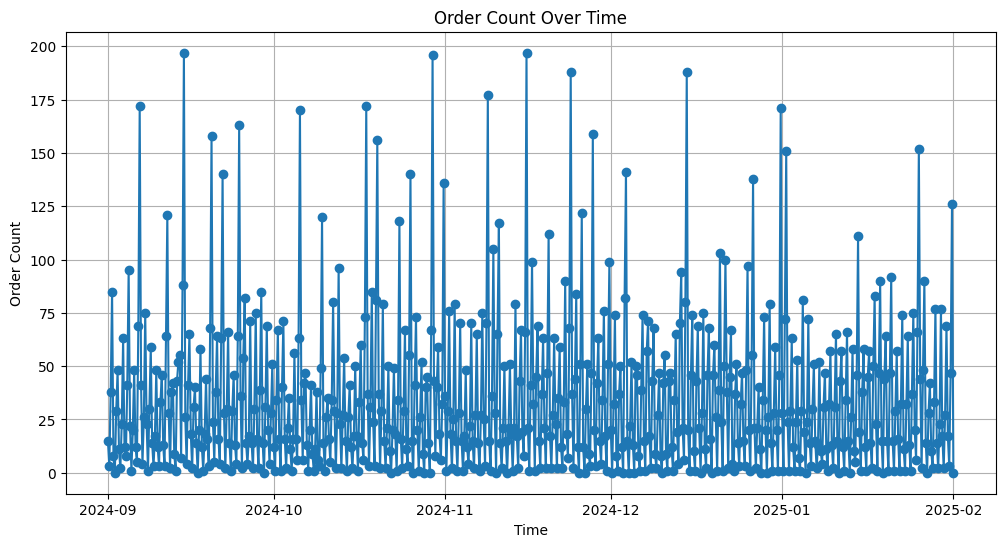

<Figure size 1200x600 with 0 Axes>

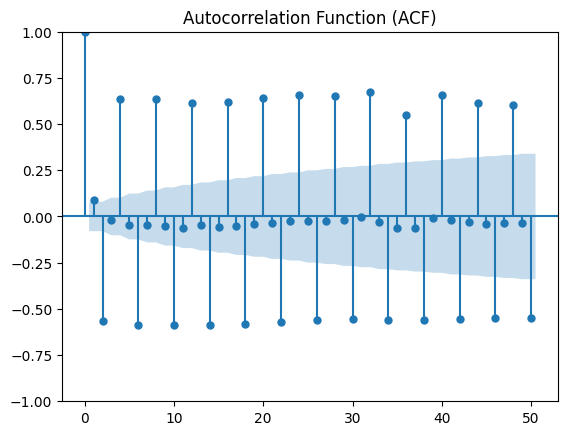

<Figure size 1200x800 with 0 Axes>

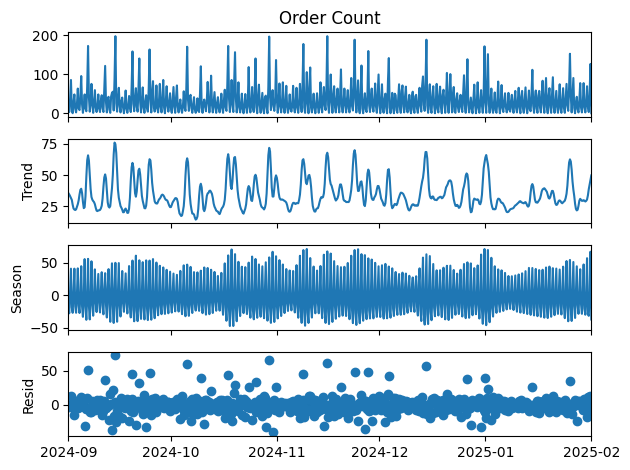

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import STL


# 📌 1️⃣ Vẽ biểu đồ chuỗi thời gian
plt.figure(figsize=(12, 6))
plt.plot(processed_df.index, processed_df["Order Count"], marker='o', linestyle='-')
plt.xlabel("Time")
plt.ylabel("Order Count")
plt.title("Order Count Over Time")
plt.grid()
plt.show()

# 📌 2️⃣ Kiểm tra tự tương quan ACF
plt.figure(figsize=(12, 6))
plot_acf(processed_df["Order Count"], lags=50)
plt.title("Autocorrelation Function (ACF)")
plt.show()

# 📌 3️⃣ Phân rã chuỗi thời gian bằng STL
period = 4  # Thay đổi tùy theo dữ liệu
stl = STL(processed_df["Order Count"], period=period)
result = stl.fit()

plt.figure(figsize=(12, 8))
result.plot()
plt.show()


KIỂM TRA ĐỘ DỪNG CỦA ORDER COUNT BẰNG BIỂU ĐỒ ACF
- Các giá trị ACF dao động khá lớn ở những độ trễ đầu (lag 1-10), thậm chí có giá trị vượt ra khỏi vùng tin cậy, điều này cho thấy có thể có sự tự tương quan mạnh trong dữ liệu, dấu hiệu của một chuỗi không có tính dừng.
- Từ lag 11 trở đi, ACF nằm chủ yếu trong vùng xanh, nghĩa là sự tự tương quan dần giảm, đây là một dấu hiệu tốt hơn về tính dừng, nhưng chưa đủ để kết luận.
- Lag 36 ACF chạm 0, điều này có thể cho thấy chuỗi có xu hướng suy giảm tự tương quan theo thời gian, nhưng nếu độ trễ cần quá lớn để đạt đến trạng thái này, chuỗi vẫn có thể có đơn vị gốc.
💡 Kết luận sơ bộ: Với việc ACF vượt ra khỏi vùng tin cậy ở nhiều lag ban đầu, khả năng chuỗi có tính dừng là không chắc chắn. Tuy nhiên, vì nó giảm dần về 0 sau lag 11, có thể có tính dừng một phần. Cách tốt nhất là dùng thêm phương pháp khác để kiểm tra độ dừng, như ADF hoặc KPSS.

<Figure size 800x400 with 0 Axes>

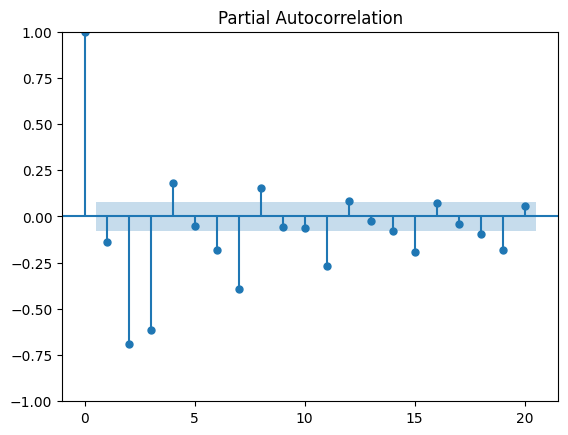

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plot_pacf(processed_df['Order Count'].diff().dropna(), lags=20)
plt.show()


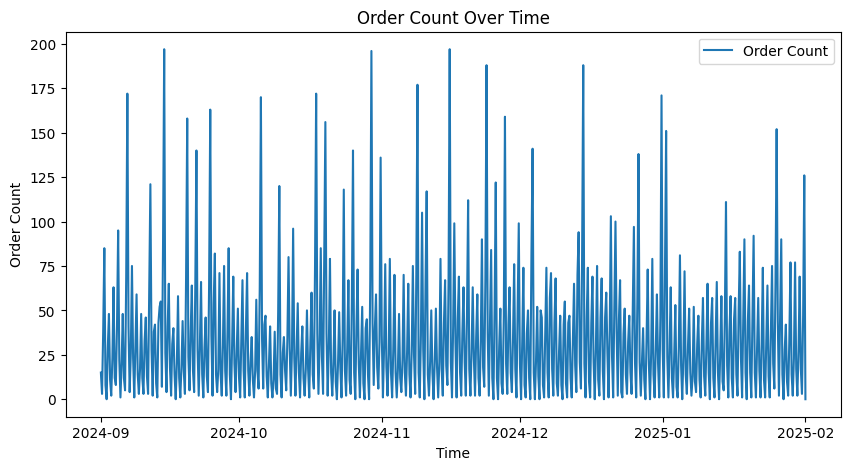

ADF Statistic: -6.101878182372185
p-value: 9.791112896941911e-08
Critical Values:
   1%: -3.4414256033746606
   5%: -2.8664262627821473
   10%: -2.569372254520843

✅ Chuỗi thời gian có tính dừng (p-value < 0.05)


In [45]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller



# Vẽ đồ thị chuỗi thời gian để quan sát trực quan
plt.figure(figsize=(10, 5))
plt.plot(processed_df["Order Count"], label="Order Count")
plt.xlabel("Time")
plt.ylabel("Order Count")
plt.title("Order Count Over Time")
plt.legend()
plt.show()

# Kiểm định Augmented Dickey-Fuller (ADF)
def test_stationarity(series):
    result = adfuller(series.dropna())  # Loại bỏ NaN nếu có
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value}")
    
    if result[1] < 0.05:
        print("\n✅ Chuỗi thời gian có tính dừng (p-value < 0.05)")
    else:
        print("\n❌ Chuỗi thời gian không có tính dừng (p-value >= 0.05), cần lấy sai phân.")

# Kiểm tra tính dừng của cột Order Count
test_stationarity(processed_df["Order Count"])


GIẢI THÍCH TỪNG CHỈ SỐ TRONG KẾT QUẢ
ADF Statistic = -8.2322
Đây là giá trị thống kê của kiểm định Dickey-Fuller.
-> Giá trị này càng nhỏ (âm càng lớn) thì chuỗi thời gian càng có tính dừng.

p-value = 6.02e-13 (~0.0000000000006)
Đây là xác suất để giả thuyết H₀ (chuỗi không dừng) đúng.
Vì p-value < 0.05, bác bỏ giả thuyết H₀.
->chuỗi thời gian có tính dừng.

Critical Values (Ngưỡng kiểm định)
1% mức ý nghĩa (-3.4418)
5% mức ý nghĩa (-2.8666)
10% mức ý nghĩa (-2.5694)
→ Nếu ADF Statistic nhỏ hơn một trong các giá trị này, ta bác bỏ giả thuyết H₀.

🔍 Theo kết quả, ADF Statistic (-8.2322) nhỏ hơn tất cả các mức (-3.4418, -2.8666, -2.5694), chứng tỏ chuỗi có tính dừng rất mạnh.

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import kpss

# Kiểm tra nếu 'Order Hour Range' chưa phải chỉ mục thì đặt lại
if not isinstance(processed_df.index, pd.DatetimeIndex):
    processed_df.set_index("Order Hour Range", inplace=True)


# Kiểm định KPSS
def test_kpss(series):
    result = kpss(series.dropna(), regression="c")  # "c" kiểm tra tính dừng có hằng số; dùng "ct" nếu muốn kiểm tra có xu hướng
    print("KPSS Statistic:", result[0])
    print("p-value:", result[1])
    print("Critical Values:")
    for key, value in result[3].items():
        print(f"   {key}: {value}")
    
    if result[1] < 0.05:
        print("\n❌ Chuỗi thời gian không có tính dừng (p-value < 0.05), cần lấy sai phân.")
    else:
        print("\n✅ Chuỗi thời gian có tính dừng (p-value >= 0.05)")

# Kiểm tra tính dừng của cột Order Count
test_kpss(processed_df["Order Count"])

KPSS Statistic: 0.0746521619425213
p-value: 0.1
Critical Values:
   10%: 0.347
   5%: 0.463
   2.5%: 0.574
   1%: 0.739

✅ Chuỗi thời gian có tính dừng (p-value >= 0.05)


C:\Users\minhh\AppData\Local\Temp\ipykernel_18972\295042336.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression="c")  # "c" kiểm tra tính dừng có hằng số; dùng "ct" nếu muốn kiểm tra có xu hướng


Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[4] intercept   : AIC=995.196, Time=0.38 sec
 ARIMA(0,0,0)(0,0,0)[4] intercept   : AIC=1050.934, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[4] intercept   : AIC=1019.892, Time=0.11 sec
 ARIMA(0,0,1)(0,0,1)[4] intercept   : AIC=1024.827, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[4]             : AIC=1111.982, Time=0.00 sec
 ARIMA(2,0,2)(0,0,1)[4] intercept   : AIC=inf, Time=0.28 sec
 ARIMA(2,0,2)(1,0,0)[4] intercept   : AIC=inf, Time=0.28 sec
 ARIMA(2,0,2)(2,0,1)[4] intercept   : AIC=inf, Time=0.46 sec
 ARIMA(2,0,2)(1,0,2)[4] intercept   : AIC=988.945, Time=0.49 sec
 ARIMA(2,0,2)(0,0,2)[4] intercept   : AIC=inf, Time=0.43 sec
 ARIMA(2,0,2)(2,0,2)[4] intercept   : AIC=inf, Time=0.53 sec
 ARIMA(1,0,2)(1,0,2)[4] intercept   : AIC=inf, Time=0.25 sec
 ARIMA(2,0,1)(1,0,2)[4] intercept   : AIC=969.387, Time=0.45 sec
 ARIMA(2,0,1)(0,0,2)[4] intercept   : AIC=1014.860, Time=0.27 sec
 ARIMA(2,0,1)(1,0,1)[4] intercept   : AIC=1000.892, Time=0.30 sec


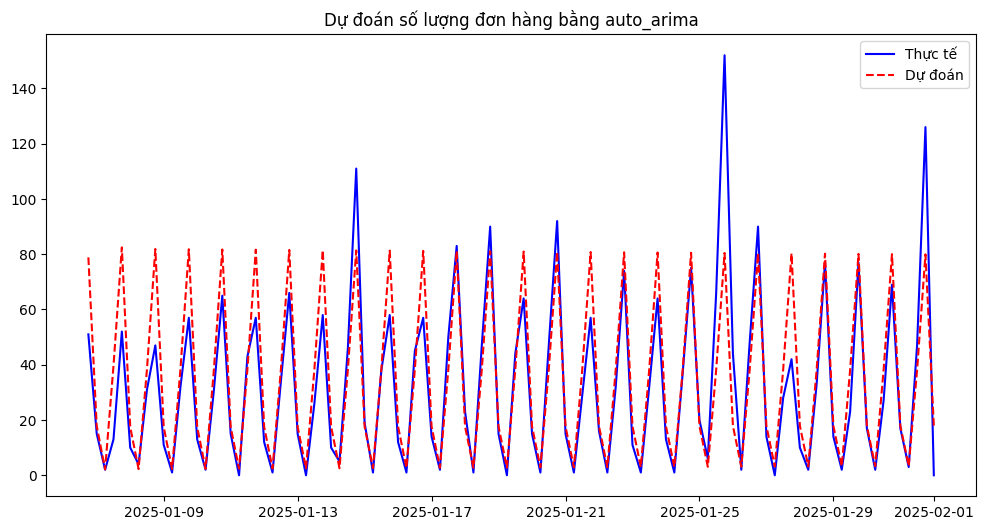

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima  # Thư viện auto_arima
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 📌 Kiểm tra processed_df trước khi copy
if 'processed_df' not in locals():
    raise ValueError("processed_df chưa được định nghĩa!")

df = processed_df.copy()
#df = df.asfreq('6h')

df = df.dropna(subset=['Order Count'])  # ⚠️ Thêm dòng này để loại bỏ NaN

#df.index.freq = '6h'
#print(df.index.freq)  # Kiểm tra tần suất của index



# Kiểm tra cột dữ liệu có tồn tại không
if 'Order Count' not in df.columns:
    raise KeyError("Cột 'Order Count' không tồn tại trong DataFrame!")

# Sắp xếp theo thời gian (theo index, vì 'Order Hour Range' đã là index)
df.sort_index(inplace=True)

# 🚀 5-Fold Cross Validation với TimeSeriesSplit
n_splits = 5  # 🔄 Giảm số lượng split nếu dữ liệu ít
tscv = TimeSeriesSplit(n_splits=n_splits)

mse_scores, mae_scores, r2_scores, r2_adj_scores = [], [], [], []

# 📌 Tham số ARIMA (tự động tìm tham số với auto_arima)
for i, (train_idx, test_idx) in enumerate(tscv.split(df)):
    train, test = df.iloc[train_idx], df.iloc[test_idx]

    if len(train) == 0 or len(test) == 0:
        print(f"⚠ Bỏ qua Fold {i+1} vì train/test rỗng!")
        continue

    # Huấn luyện mô hình với auto_arima
    try:
        # Tìm tham số tối ưu với auto_arima
        train_series = train['Order Count']
        test_series = test['Order Count']
        model = auto_arima(train_series, seasonal=True, m=4, stepwise=True, trace=True)
        # ❌ KHÔNG gọi .fit() lại nữa, vì auto_arima đã fit sẵn
        predictions = model.predict(n_periods=len(test_series))


        # Tính toán độ lỗi
        mse = mean_squared_error(test['Order Count'], predictions)
        mae = mean_absolute_error(test['Order Count'], predictions)
        r2 = r2_score(test['Order Count'], predictions)

        # Tính toán R² điều chỉnh
        n = len(test)  # Số lượng quan sát
        k = model.order[0] + model.order[1] + model.order[2]  # Số tham số trong mô hình ARIMA (p + d + q)
        r2_adj = 1 - ((1 - r2) * (n - 1)) / (n - k - 1) if n - k - 1 > 0 else np.nan  # Tránh chia cho 0

        # Lưu kết quả
        mse_scores.append(mse)
        mae_scores.append(mae)
        r2_scores.append(r2)
        r2_adj_scores.append(r2_adj)

        print(f"Fold {i+1} - MSE: {mse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}, R² adj: {r2_adj:.4f}")
    except Exception as e:
        print(f"⚠ Lỗi trong Fold {i+1}: {e}")
        continue

# 📊 Kết quả trung bình sau các Fold hợp lệ
if mse_scores:
    print("\n📢 Kết quả trung bình:")
    print(f"🔹 MSE: {np.mean(mse_scores):.4f}")
    print(f"🔹 MAE: {np.mean(mae_scores):.4f}")
    print(f"🔹 R²: {np.mean(r2_scores):.4f}")
    print(f"🔹 R² adj: {np.mean(r2_adj_scores):.4f}")
else:
    print("⚠ Không có Fold nào chạy thành công!")

# 📈 Vẽ đồ thị dự đoán so với thực tế (Chỉ vẽ nếu có dữ liệu)
if len(test) > 0:
    plt.figure(figsize=(12,6))
    plt.plot(test.index, test['Order Count'], label="Thực tế", color="blue")  # Sử dụng test.index (thời gian) làm trục x
    plt.plot(test.index, predictions, label="Dự đoán", linestyle="dashed", color="red")  # Sử dụng test.index (thời gian) làm trục x
    plt.legend()
    plt.title("Dự đoán số lượng đơn hàng bằng auto_arima")
    plt.show()
else:
    print("⚠ Không có dữ liệu để vẽ biểu đồ!")


In [42]:
# Kiểm tra kiểu của index
print(type(processed_df.index))

# Kiểm tra ví dụ về giá trị trong index
print(processed_df.index[:5])  # In ra 5 giá trị đầu tiên của index

# Kiểm tra tần suất (frequency) của index
print(processed_df.index.freq)


<class 'pandas.core.indexes.datetimes.DatetimeIndex'>
DatetimeIndex(['2024-09-01 00:00:00', '2024-09-01 06:00:00',
               '2024-09-01 12:00:00', '2024-09-01 18:00:00',
               '2024-09-02 00:00:00'],
              dtype='datetime64[ns]', name='Order Hour Range', freq='6h')
<6 * Hours>


Dự báo bằng XGBoost



👉 Number of features used (k): 4
Fold 1 → MSE: 216.52 | MAE: 9.51 | R2: 0.82 | R2 Adjusted: 0.81
Fold 2 → MSE: 311.08 | MAE: 10.59 | R2: 0.82 | R2 Adjusted: 0.81
Fold 3 → MSE: 234.58 | MAE: 9.13 | R2: 0.82 | R2 Adjusted: 0.81
Fold 4 → MSE: 287.81 | MAE: 10.50 | R2: 0.80 | R2 Adjusted: 0.79
Fold 5 → MSE: 80.29 | MAE: 6.14 | R2: 0.92 | R2 Adjusted: 0.91

Average Cross-Validation Scores:
Avg MSE        : 226.05519395051505
Avg MAE        : 9.173696675926152
Avg R2         : 0.8332891464233398
Avg R2 Adjusted: 0.8263428608576456


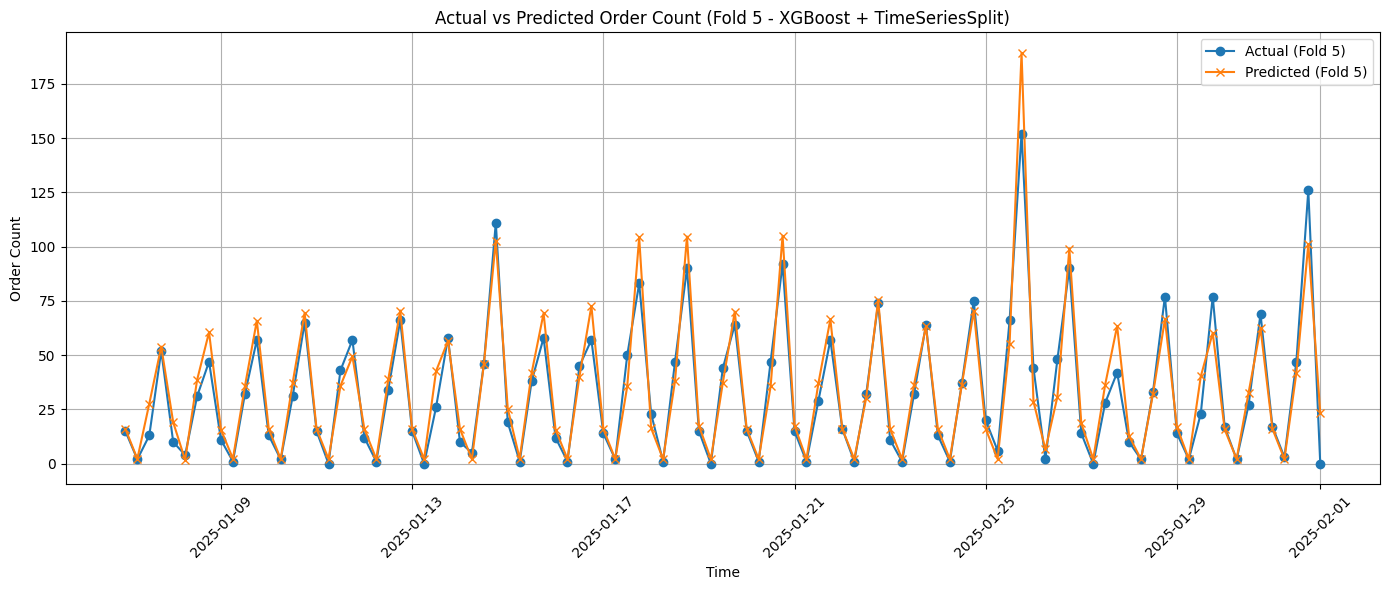

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ======= Tạo đặc trưng dạng lag =======
def create_lag_features(df, n_lags=4):
    df_lagged = df.copy()
    for i in range(1, n_lags + 1):
        df_lagged[f'lag_{i}'] = df_lagged['Order Count'].shift(i)
    df_lagged = df_lagged.dropna()
    return df_lagged

# ======= Dữ liệu đầu vào: processed_df đã có sẵn =======
df_lagged = create_lag_features(processed_df, n_lags=4)
X = df_lagged.drop(columns=['Order Count'])
y = df_lagged['Order Count']

# Kiểm tra số đặc trưng
print("👉 Number of features used (k):", X.shape[1])

# ======= TimeSeriesSplit (5 fold) =======
tscv = TimeSeriesSplit(n_splits=5)

# Danh sách lưu metric
mse_list, mae_list, r2_list, r2_adj_list = [], [], [], []

# Vẽ Fold cuối (fold 5)
plt.figure(figsize=(14, 6))
fold = 1

for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Tính metric
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Tính Adjusted R²
    n = len(y_test)
    k = X.shape[1]
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - k - 1)

    # Lưu kết quả
    mse_list.append(mse)
    mae_list.append(mae)
    r2_list.append(r2)
    r2_adj_list.append(r2_adj)

    print(f"Fold {fold} → MSE: {mse:.2f} | MAE: {mae:.2f} | R2: {r2:.2f} | R2 Adjusted: {r2_adj:.2f}")

    if fold == 5:
        plt.plot(y_test.index, y_test, label='Actual (Fold 5)', marker='o')
        plt.plot(y_test.index, y_pred, label='Predicted (Fold 5)', marker='x')

    fold += 1

# ======= Trung bình các chỉ số =======
print("\nAverage Cross-Validation Scores:")
print("Avg MSE        :", sum(mse_list) / len(mse_list))
print("Avg MAE        :", sum(mae_list) / len(mae_list))
print("Avg R2         :", sum(r2_list) / len(r2_list))
print("Avg R2 Adjusted:", sum(r2_adj_list) / len(r2_adj_list))

# ======= Biểu đồ dự đoán của Fold cuối =======
plt.xlabel("Time")
plt.ylabel("Order Count")
plt.title("Actual vs Predicted Order Count (Fold 5 - XGBoost + TimeSeriesSplit)")
plt.xticks(rotation=45)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


- MSE (Mean Squared Error):

MSE dao động từ 80.29 đến 311.08, cho thấy mô hình có thể dự đoán rất chính xác ở một số fold (đặc biệt là fold 5) nhưng đôi khi có sự chệch lệch đáng kể (fold 2, fold 4). MSE thấp hơn là tốt, nhưng khi có sự chênh lệch lớn, bạn cần xem xét thêm các đặc trưng hoặc tiền xử lý.

- MAE (Mean Absolute Error):

MAE dao động từ 6.14 đến 10.59, mức MAE cho thấy mô hình có thể dự báo gần đúng trong nhiều trường hợp, tuy nhiên, fold 4 có MAE cao hơn một chút. Điều này cho thấy có thể có sự bất ổn trong các dữ liệu ở fold đó.

- R² (Coefficient of Determination):

R² dao động từ 0.80 đến 0.92, một R² cao (trên 0.8) cho thấy mô hình có khả năng giải thích phần lớn sự biến động của dữ liệu. Fold 5 có R² cao nhất (0.92), cho thấy mô hình có thể dự báo rất chính xác ở fold này.

- Adjusted R²:

R² điều chỉnh cũng dao động khá đều từ 0.79 đến 0.91. R² điều chỉnh giữ được tính ổn định giữa các fold, cho thấy mô hình không quá bị ảnh hưởng bởi số lượng đặc trưng hay overfitting.


🧠 ĐÁNH GIÁ TỔNG QUAN
Tổng thể, mô hình XGBoost đang hoạt động khá tốt, với R² trung bình là 0.83, nghĩa là mô hình giải thích khoảng 83% biến động của dữ liệu (có thể được cải thiện thêm, nhưng khá ổn so với dữ liệu chuỗi thời gian).

Kết quả tốt ở fold cuối (fold 5) với R² cao 0.92 và MAE thấp 6.14, cho thấy mô hình có thể học được rất tốt trong những trường hợp dữ liệu rõ ràng hơn.

Các fold khác có sự dao động rõ rệt trong MSE và MAE, đặc biệt là fold 2 và fold 4. Điều này có thể chỉ ra rằng mô hình gặp khó khăn khi đối mặt với một số mẫu dữ liệu, có thể là vì:

Sự thay đổi đột ngột trong số lượng đơn hàng ở những fold đó.

Các yếu tố không được mô hình hóa đầy đủ như: xu hướng theo tuần, theo mùa, hoặc sự kiện đặc biệt (lễ hội, khuyến mãi).


🧠 CÁCH GIẢI QUYẾT: thử so sánh các mô hình khác.

C:\Users\minhh\AppData\Local\Temp\ipykernel_15608\1686153699.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_lagged[f'lag_{i}'] = df_lagged['Order Count'].shift(i)
C:\Users\minhh\AppData\Local\Temp\ipykernel_15608\1686153699.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_lagged[f'lag_{i}'] = df_lagged['Order Count'].shift(i)
C:\Users\minhh\AppData\Local\Temp\ipykernel_15608\1686153699.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, whic

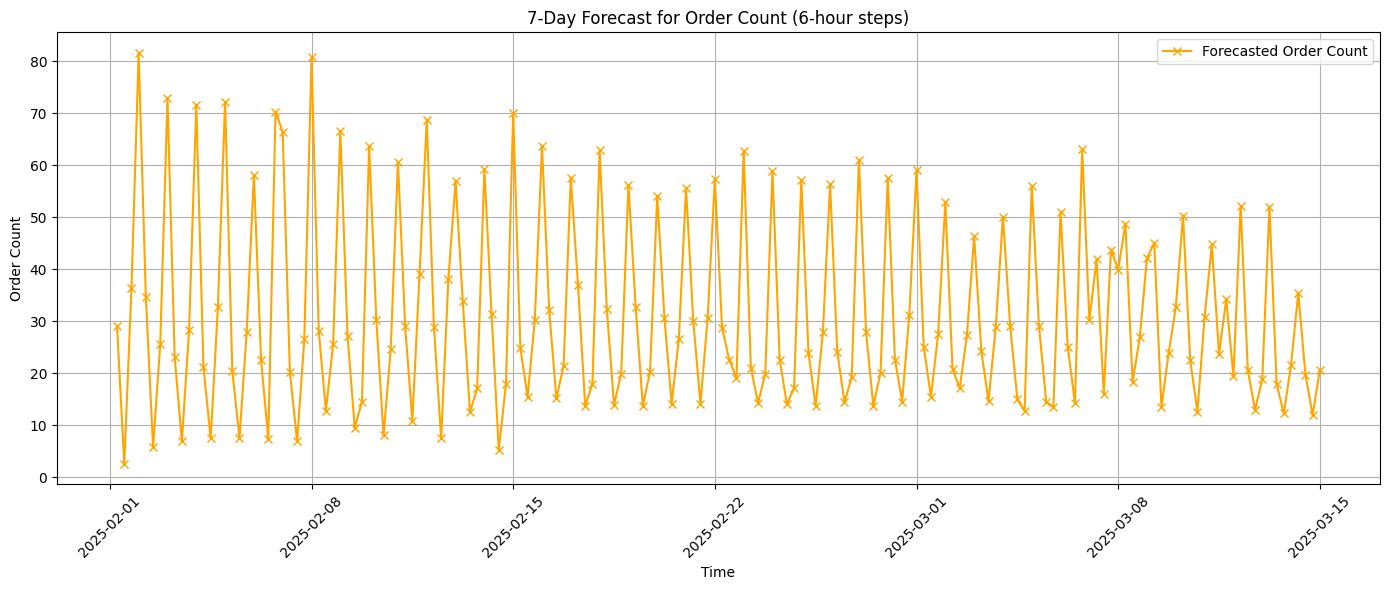

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# === 1. TẠO ĐẶC TRƯNG LAG ===
def create_lag_features(df, n_lags=4):
    df_lagged = df.copy()
    for i in range(1, n_lags + 1):
        df_lagged[f'lag_{i}'] = df_lagged['Order Count'].shift(i)
    df_lagged = df_lagged.dropna()
    return df_lagged

# === 2. GIẢ SỬ processed_df ĐÃ TỒN TẠI ===
# Ví dụ tạo giả:
# processed_df = your_dataframe_with_order_count_and_datetime_index

n_lags = 168  # Sử dụng 168 giờ (7 ngày) làm độ trễ
df_lagged = create_lag_features(processed_df, n_lags=n_lags)

# === 3. CHIA DỮ LIỆU HUẤN LUYỆN ===
X = df_lagged.drop(columns=['Order Count'])
y = df_lagged['Order Count']

# Huấn luyện mô hình
model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model.fit(X, y)

# === 4. DỰ BÁO 7 NGÀY TIẾP THEO ===
# Lấy n_lags giá trị cuối cùng làm dữ liệu đầu vào ban đầu
last_window = processed_df['Order Count'].tail(n_lags).tolist()

forecast_next = []
for _ in range(168):  # 168 bước tương đương 7 ngày, mỗi bước 6h
    input_array = pd.DataFrame([last_window[-n_lags:]], columns=[f'lag_{i+1}' for i in range(n_lags)])
    y_pred = model.predict(input_array)[0]
    forecast_next.append(y_pred)
    last_window.append(y_pred)

# === 5. TẠO THỜI GIAN CHO DỰ BÁO ===
forecast_index = pd.date_range(
    start=processed_df.index[-1] + pd.Timedelta(hours=6),
    periods=168,
    freq='6h'
)

forecast_df = pd.DataFrame(forecast_next, index=forecast_index, columns=['Forecasted Order Count'])


# === 6. VẼ BIỂU ĐỒ ===
plt.figure(figsize=(14, 6))
plt.plot(forecast_df.index, forecast_df['Forecasted Order Count'], label='Forecasted Order Count', color='orange', marker='x')
plt.xlabel("Time")
plt.ylabel("Order Count")
plt.title("7-Day Forecast for Order Count (6-hour steps)")
plt.xticks(rotation=45)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


NHẬN XÉT TỔNG QUAN:
- Tính chu kỳ rõ ràng:

Dự báo có dạng hình sin lặp đi lặp lại với chu kỳ khoảng 1–2 ngày.

Điều này thể hiện rằng mô hình đã học được đặc điểm tuần hoàn trong dữ liệu (có thể là theo ngày hoặc theo ca làm việc).

- Biên độ dao động giảm dần:

Từ đầu đến cuối biểu đồ, biên độ (khoảng cách giữa đỉnh và đáy) có xu hướng giảm dần.

Có thể là do đặc trưng lag làm mất dần thông tin mùa vụ xa hơn (forecast loop dần dần sử dụng giá trị dự đoán thay vì thực tế).

- Mức trung bình giảm nhẹ:

Số lượng đơn hàng trung bình có vẻ giảm theo thời gian, đặc biệt gần về cuối chuỗi dự báo.

Đây có thể là do mô hình bị suy giảm thông tin thực hoặc xu hướng trong dữ liệu gốc là đi xuống.

- Đỉnh và đáy khá cực đoan:

Một số điểm đỉnh gần 80, điểm đáy dưới 10, chứng tỏ mô hình vẫn có xu hướng dự báo mạnh.

Điều này có thể phản ánh đúng tính biến động mạnh trong thực tế, hoặc do overfitting một phần chu kỳ.

In [21]:
print(df_lagged.tail(10))  # Kiểm tra 10 dòng cuối cùng của df_lagged


                     Order Count  lag_1  lag_2  lag_3  lag_4
Order Hour Range                                            
2025-01-29 18:00:00           77   23.0    2.0   14.0   77.0
2025-01-30 00:00:00           17   77.0   23.0    2.0   14.0
2025-01-30 06:00:00            2   17.0   77.0   23.0    2.0
2025-01-30 12:00:00           27    2.0   17.0   77.0   23.0
2025-01-30 18:00:00           69   27.0    2.0   17.0   77.0
2025-01-31 00:00:00           17   69.0   27.0    2.0   17.0
2025-01-31 06:00:00            3   17.0   69.0   27.0    2.0
2025-01-31 12:00:00           47    3.0   17.0   69.0   27.0
2025-01-31 18:00:00          126   47.0    3.0   17.0   69.0
2025-02-01 00:00:00            0  126.0   47.0    3.0   17.0
